In [1]:
import pandas as pd
import numpy as np
#import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.tsa.stattools import ccf, grangercausalitytests
import matplotlib.cm as cm
import matplotlib.colors as mcolors
#import networkx as nx
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from matplotlib.colors import TwoSlopeNorm

In [2]:
def seasonal_average(da):
    da2=da.groupby('time.year').mean('time')
    return(da2)

def stdize_ssavg(da):
    da2=(da-da.mean())/da.std()
    return da2

def extract_seasonal_data(array, seasons):
    """
    Extract data from the array for specific seasons (months).
    - A subset of the original array with only the data for the specified months.
    """
    # Make sure the 'time' dimension has a 'month' coordinate
    if 'time' in array.coords:
        # Extract month from the 'time' dimension
        months = array['time'].dt.month
        
        # Filter based on the provided seasons (months)
        seasonal_data = array.sel(time=months.isin(seasons))
        
        return seasonal_data
    else:
        raise ValueError("The input array does not contain a 'time' dimension.")
        
def compute_anomaly(array):
    anomaly=array.groupby('time.month')-array.groupby('time.month').mean('time')
    return(anomaly)

def shift_december(da):
    time_df = pd.to_datetime(da['time'])
    # Create a boolean mask for times in December
    time_series=pd.Series(time_df)
    mask = time_series.dt.month == 12
    time_series.loc[mask] = time_series.loc[mask] + pd.DateOffset(years=1)
    # Convert to numpy datetime64[D]
    time_df_upd = time_series.values.astype('datetime64[D]')
    #display(time_df_upd)
    d={'time':time_df_upd}
    da_new=da.assign_coords(d)
    return da_new

def weight_by_latitude(da):
    """Weight data array by cosine of latitude."""
    weights = np.cos(np.deg2rad(da['lat']))
    weighted_da = da * weights
    return weighted_da

def sea_mask(da):
    landsea_mask=xr.open_dataset('landseamask.nc') # mask values 0 (sea) or 1 (land)
    landsea_mask_interp = landsea_mask['mask'].interp(
    lat=da.lat,
    lon=da.lon,
    method='nearest') ##map my mask 0.5° on my 0.25° grid
    #print(landsea_mask.sel(lat=-32.25,lon=-50.25)['mask'].values)
    
    masked_da=da.where(landsea_mask_interp==1)
    return masked_da

In [3]:
def df_xr_prep(df):
    da=df.to_xarray()
    da=da.rename({'index':'year'})
    return da

##La Plata
#SON
era_SON_LaPlata_df=pd.read_csv('data_ready/7.csv',index_col='Unnamed: 0')

#era_SON_LaPlata_df=era_SON_LaPlata_df.rename(index_col='year')
era_SON_LaPlata_array=era_SON_LaPlata_df.to_xarray()
era_SON_LaPlata_array=era_SON_LaPlata_array.rename({'index':'year'})

#DJF
era_DJF_LaPlata_df=pd.read_csv('data_ready/6_with_IOBW_VB.csv', index_col='Unnamed: 0')
era_DJF_LaPlata_array=df_xr_prep(era_DJF_LaPlata_df)

##Andes
#SON
era_SON_Andes_df=pd.read_csv('data_ready/5.csv',index_col='Unnamed: 0')
era_SON_Andes_array=df_xr_prep(era_SON_Andes_df)

#DJF
era_DJF_Andes_df=pd.read_csv('data_ready/4_with_IOBW_VB.csv', index_col='Unnamed: 0')
era_DJF_Andes_array=df_xr_prep(era_DJF_Andes_df)
display(era_DJF_Andes_array)

<xarray.Dataset> Size: 8kB
Dimensions:        (year: 73)
Coordinates:
  * year           (year) int64 584B 1951 1952 1953 1954 ... 2022 2023 2024 1950
Data variables: (12/13)
    t_Andes        (year) float64 584B -1.791 0.5614 -0.2617 ... 0.6017 nan
    precip_Andes   (year) float64 584B 0.129 0.4549 -1.375 ... -0.2223 -1.51 nan
    ENSO           (year) float64 584B -0.6866 0.5838 0.3068 ... 1.632 nan
    IOD            (year) float64 584B 0.2555 0.6281 1.26 ... 0.9651 4.209 nan
    EDJ            (year) float64 584B 1.783 0.6677 -0.5056 ... 0.1875 nan
    EDJ_lat        (year) float64 584B -0.6985 1.359 -0.9556 ... -2.241 nan
    ...             ...
    SPV            (year) float64 584B 0.2633 -0.6312 1.451 ... 1.702 1.85 nan
    A_SAM          (year) float64 584B 0.233 -1.135 -2.197 ... 1.774 0.05365 nan
    S_SAM          (year) float64 584B 0.6038 -1.058 0.1437 ... 1.93 1.88 nan
    IOBW           (year) float64 584B -1.546 0.8591 -0.3374 ... 2.389 nan
    VB             (year) float64 584B -0.4348 -0.7162 1.351 ... 1.365 1.083 nan
    VB_class       (year) object 584B 'Early' 'Early' 'Late' ... 'Late' 'Late'

In [4]:
def var_prepper(da, months_list, wghts_bool=True):
    ##1 Anomalies
    da_an=compute_anomaly(da)
    
    ##2 detrending
    p = da_an.polyfit(dim='time', deg=1, skipna=False)
    coeffs = p[list(p.data_vars)[0]]   # or p.t2m_polyfit_coefficients
    t_fit = xr.polyval(da_an['time'], coeffs)
    da_detr=da_an - t_fit
    
    ##3 weight by latitude (if necessary)
    if wghts_bool==True:
        da_wght=weight_by_latitude(da_detr)
    else:
        da_wght=da_detr
    ##4 extract seasonal data and standardise it again
    da_season=extract_seasonal_data(da_wght,months_list)
    if 12 in months_list:
        da_season_mean=stdize_ssavg(seasonal_average(shift_december(da_season)))
    else: 
        da_season_mean=stdize_ssavg(seasonal_average((da_season)))
        
    ##5 mask the ocean
    da_masked=sea_mask(da_season_mean)
    
    return da_masked

In [5]:
#load temperature era5 data
t_era=xr.open_dataset('data/era5_t2m.nc') #variable name is t2m
t_era=t_era.rename({'valid_time':'time','latitude':'lat','longitude':'lon'})
t_total=t_era.sel(time=slice('1950','2024'),lat=slice(-20,-55),lon=slice(-76,-49)) 

t_whole_SON=var_prepper(t_total, [9,10,11], wghts_bool=False)
t_whole_DJF=var_prepper(t_total, [12,1,2], wghts_bool=False)

In [6]:
##Era 5 precip data
pr_era=xr.open_dataset('data/era5_tp.nc')
pr_era=pr_era.rename({'valid_time':'time','latitude':'lat','longitude':'lon'})
pr_total=pr_era.sel(time=slice('1950','2024'),lat=slice(-20,-55),lon=slice(-76,-49)) 

pr_whole_SON=var_prepper(pr_total, [9,10,11], wghts_bool=False)
pr_whole_DJF=var_prepper(pr_total, [12,1,2], wghts_bool=False)

In [7]:
t_whole_SON.sel(lat=-32.25,lon=-50.25)

<xarray.Dataset> Size: 1kB
Dimensions:  (year: 75)
Coordinates:
    lat      float64 8B -32.25
    lon      float64 8B -50.25
  * year     (year) int64 600B 1950 1951 1952 1953 1954 ... 2021 2022 2023 2024
Data variables:
    t2m      (year) float64 600B nan nan nan nan nan nan ... nan nan nan nan nan

In [8]:
print(np.unique(t_whole_SON.values))

[<bound method Mapping.values of <xarray.Dataset> Size: 9MB
 Dimensions:  (year: 75, lat: 141, lon: 105)
 Coordinates:
   * lat      (lat) float64 1kB -20.0 -20.25 -20.5 -20.75 ... -54.5 -54.75 -55.0
   * lon      (lon) float64 840B -76.0 -75.75 -75.5 -75.25 ... -50.5 -50.25 -50.0
   * year     (year) int64 600B 1950 1951 1952 1953 1954 ... 2021 2022 2023 2024
 Data variables:
     t2m      (year, lat, lon) float64 9MB nan nan nan nan ... nan nan nan nan>  ]


In [9]:
#display(t_LaPlata_ssavg_SON)

years_to_drop = [1950, 2002, 2019, 2025]

def exclude_years_xr(xr_obj, years):
    return xr_obj.sel(year=~xr_obj.year.isin(years))

##SON
t_whole_SON_ex=exclude_years_xr(t_whole_SON, years_to_drop)
pr_whole_SON_ex=exclude_years_xr(pr_whole_SON, years_to_drop)

##DJF
cut_years=[1950,2003,2020,2025]
t_whole_DJF_ex=exclude_years_xr(t_whole_DJF, cut_years)
pr_whole_DJF_ex=exclude_years_xr(pr_whole_DJF, cut_years)


In [10]:
##SON data
ds_SON = xr.merge([t_whole_SON_ex,pr_whole_SON_ex, era_SON_LaPlata_array])

##DJF data
ds_DJF=xr.merge([t_whole_DJF_ex,pr_whole_DJF_ex, era_DJF_LaPlata_array])

In [11]:
ds_SON

<xarray.Dataset> Size: 17MB
Dimensions:         (year: 72, lat: 141, lon: 105)
Coordinates:
  * lat             (lat) float64 1kB -20.0 -20.25 -20.5 ... -54.5 -54.75 -55.0
  * lon             (lon) float64 840B -76.0 -75.75 -75.5 ... -50.5 -50.25 -50.0
  * year            (year) int64 576B 1951 1952 1953 1954 ... 2022 2023 2024
Data variables:
    t2m             (year, lat, lon) float64 9MB nan nan nan nan ... nan nan nan
    tp              (year, lat, lon) float64 9MB nan nan nan nan ... nan nan nan
    t_LaPlata       (year) float64 576B 1.008 -0.3405 0.001028 ... 1.707 1.963
    precip_LaPlata  (year) float64 576B 1.251 -1.636 2.576 ... 1.411 -0.9275
    ENSO            (year) float64 576B 0.8577 -0.08958 0.6573 ... 1.719 -0.33
    IOD             (year) float64 576B 0.1126 -0.4963 0.1753 ... 3.25 0.8168
    EDJ             (year) float64 576B -0.4128 -0.3213 ... -0.2175 -0.763
    EDJ_lat         (year) float64 576B 1.568 -1.369 0.8338 ... -0.1452 1.446
    EDJ_lat_nostd   (year) float64 576B -48.64 -53.79 -49.93 ... -51.64 -48.86
    SPV             (year) float64 576B -1.639 0.7289 -1.065 ... 0.9296 -0.05547
    A_SAM           (year) float64 576B -0.6832 0.7533 ... -0.6919 -0.4684
    S_SAM           (year) float64 576B -2.402 -0.386 -1.018 ... 0.5597 0.9627

Whole Area Spring ERA5 data

In [12]:
import sys
sys.path.insert(0, "~/work/whole_period_effects")  # add Folder_2 path to search list

from whole_period_effects.Functions import plot_map, subplots_map, plot_map_circ, subplots_map_circ

#probably do not work!
sys.path.insert(0, '~/work/Hindcast')
from Hindcast.Functions_bootstrap import modify_driver_list #, bootstrap_map, bootstrap_regression_cell

In [13]:
def bootstrap_regression_cell(
    y,
    drivers,
    driver_vars,
    n_boot=500,
    sample_size=200,
    add_intercept=True,
    seed=42,
    total_eff=False,
):

    n_samples = y.shape[0]
    n_drivers = len(driver_vars)

    # ------------------------------------------------------------
    # Driver dictionary
    # ------------------------------------------------------------

    driver_data = {
        var: drivers[j, :]
        for j, var in enumerate(driver_vars)
    }

    # ------------------------------------------------------------
    # Controls
    # ------------------------------------------------------------

    controls_dict = modify_driver_list(
        driver_vars,
        total_eff=total_eff
    )

    # ------------------------------------------------------------
    # Output
    # ------------------------------------------------------------

    r2_out = np.full(
        (n_boot, n_drivers),
        np.nan,
        dtype=np.float64
    )

    coef_out = np.full(
        (n_boot, n_drivers),
        np.nan,
        dtype=np.float64
    )

    # ------------------------------------------------------------
    # RNG
    #
    # Important: different spatial cells get different streams.
    # ------------------------------------------------------------

    rng = np.random.default_rng(seed)

    # ------------------------------------------------------------
    # Loop over focal drivers
    # ------------------------------------------------------------

    for d, driver in enumerate(driver_vars):

        controls = controls_dict[driver]

        if controls is None:
            regression_vars = [driver]
        else:
            regression_vars = [driver] + controls

        # --------------------------------------------------------
        # Construct X
        # --------------------------------------------------------

        X = np.column_stack([
            driver_data[var]
            for var in regression_vars
        ])

        # --------------------------------------------------------
        # Remove NaNs once
        # --------------------------------------------------------

        valid = np.isfinite(y)

        valid &= np.all(
            np.isfinite(X),
            axis=1
        )

        X = X[valid]
        y_valid = y[valid]

        n_valid = len(y_valid)

        n_predictors = X.shape[1]
        n_parameters = n_predictors + int(add_intercept)

        if n_valid <= n_parameters:
            continue

        # --------------------------------------------------------
        # Bootstrap indices
        # --------------------------------------------------------

        indices = rng.integers(
            0,
            n_valid,
            size=(n_boot, sample_size)
        )

        # --------------------------------------------------------
        # Bootstrap regression
        #

        for b in range(n_boot):

            idx = indices[b]

            Xb = X[idx]
            yb = y_valid[idx]

            # Add intercept
            if add_intercept:
                Xreg = np.empty(
                    (sample_size, n_predictors + 1),
                    dtype=np.float64
                )

                Xreg[:, 0] = 1.0
                Xreg[:, 1:] = Xb

                focal_idx = 1

            else:
                Xreg = Xb
                focal_idx = 0

            # ----------------------------------------------------
            # Least-squares regression
            # ----------------------------------------------------

            try:
                beta, residuals, rank, s = np.linalg.lstsq(
                    Xreg,
                    yb,
                    rcond=None
                )
            except np.linalg.LinAlgError:
                continue


            coef_out[b, d] = beta[focal_idx]


            y_hat = Xreg @ beta

            ss_res = np.sum(
                (yb - y_hat) ** 2
            )

            y_mean = np.mean(yb)

            ss_tot = np.sum(
                (yb - y_mean) ** 2
            )

            if ss_tot > 0:
                r2_out[b, d] = (
                    1.0
                    - ss_res / ss_tot
                )

    return r2_out, coef_out


def bootstrap_map(ds, driver_vars, target_var, n_boot=5, sample_size=200, total_eff=False):

    target_xr = ds[target_var]
            # .chunk({
            # "year": -1,
            # "lat": 6,
            # "lon": 6,
            # })
    
    drivers_array = xr.concat(
        [ds[var] for var in driver_vars],
        dim="driver"
    ).assign_coords(
        driver=driver_vars
    )

    r2, coef = xr.apply_ufunc(
    bootstrap_regression_cell,

    target_xr,
    drivers_array,

    input_core_dims=[
        ["year"],
        ["driver", "year"],
    ],

    output_core_dims=[
        ["bootstrap", "driver"],
        ["bootstrap", "driver"],
    ],

    vectorize=True,

    output_dtypes=[
            np.float64,
            np.float64,
        ],

        kwargs={
            "driver_vars": driver_vars,
            "n_boot": n_boot,
            "sample_size": sample_size,
            "add_intercept": True,
            "seed": 42,
            "total_eff": total_eff,
        },

        dask="parallelized",

        dask_gufunc_kwargs={
            "output_sizes": {
                "bootstrap": n_boot,
                "driver": len(driver_vars),
            },
            "allow_rechunk": False,
        },
    )

    #try only returning the mean values of the bootstrap samples for plotting
    coef_mean = coef.mean(dim="bootstrap", skipna=True).transpose('driver', 'lat', 'lon')
    coef_std=coef.std(dim='bootstrap', skipna=True).transpose('driver', 'lat', 'lon')
    r2_mean = r2.mean(dim="bootstrap", skipna=True).transpose('driver', 'lat', 'lon')
        
        #stippling
    prob_positive = (coef > 0).mean(dim="bootstrap", skipna=True)
    prob_negative = (coef < 0).mean(dim="bootstrap", skipna=True)
    
        # | is the or operator 
        # use 95% CI (is more strict than 80%)
    significant = (prob_positive >= 0.95) | (prob_negative >= 0.95)
    
    significant=significant.transpose('driver', 'lat', 'lon')
    
    r2_mean=r2_mean.compute()
    coef_mean=coef_mean.compute()
    coef_std=coef_std.compute()
    significant=significant.compute()
    
    return r2_mean, coef_mean, coef_std, significant

In [ ]:
drivers_SON=['ENSO', 'IOD', 'SPV', 'A_SAM', 'S_SAM']
drivers_SON_tot=drivers_SON[:3]

r2_precip_SON_direct, coef_precip_SON_direct, std_precip_SON_direct, significant_precip_SON_direct=bootstrap_map(ds=ds_SON, driver_vars=drivers_SON, target_var='tp', n_boot=100, sample_size=30)
r2_precip_SON_total, coef_precip_SON_total, std_precip_SON_total, significant_precip_SON_total=bootstrap_map(ds=ds_SON, driver_vars=drivers_SON_tot, target_var='tp', n_boot=100, sample_size=30)

r2_temp_SON_direct, coef_temp_SON_direct, std_temp_SON_direct, significant_temp_SON_direct=bootstrap_map(ds=ds_SON, driver_vars=drivers_SON, target_var='t2m', n_boot=100, sample_size=30)
r2_temp_SON_total, coef_temp_SON_total, std_temp_SON_total, significant_temp_SON_total=bootstrap_map(ds=ds_SON, driver_vars=drivers_SON_tot, target_var='t2m', n_boot=100, sample_size=30)


/home/glattus/anaconda3/envs/climate/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/glattus/anaconda3/envs/climate/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/glattus/anaconda3/envs/climate/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/glattus/anaconda3/envs/climate/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [15]:
significant_precip_SON_total.dims[1]

'lat'

('lat', 'lon')
('lat', 'lon')
('lat', 'lon')
('lat', 'lon')
('lat', 'lon')


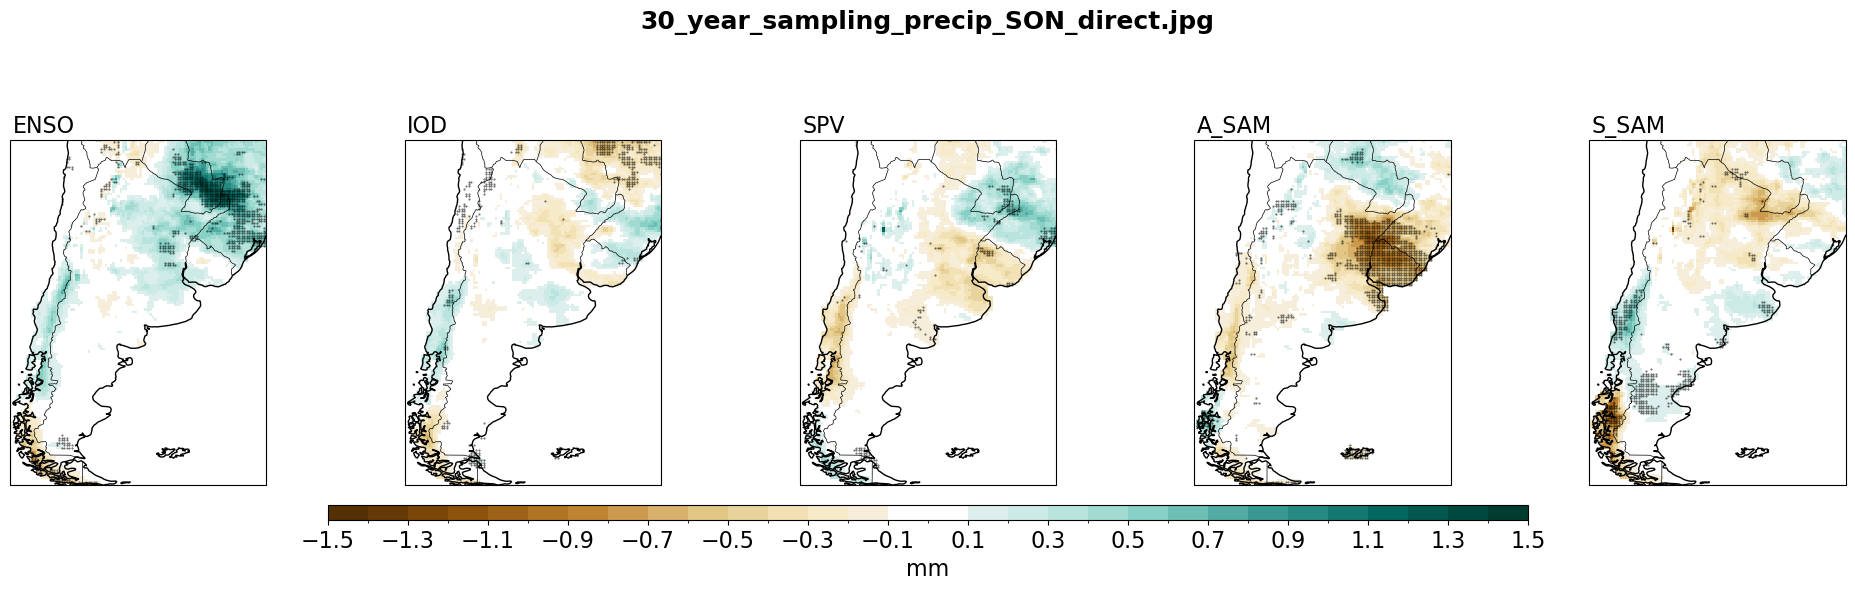

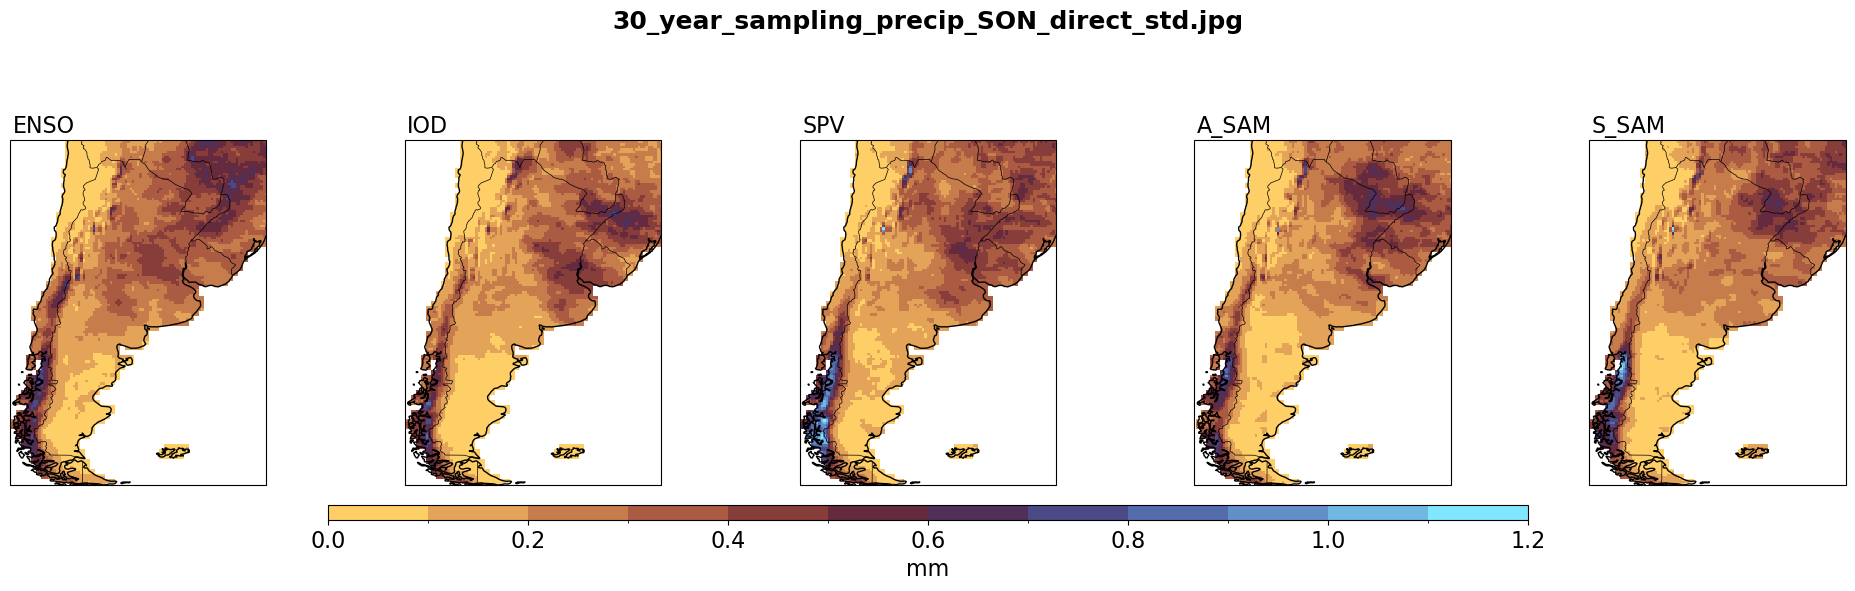

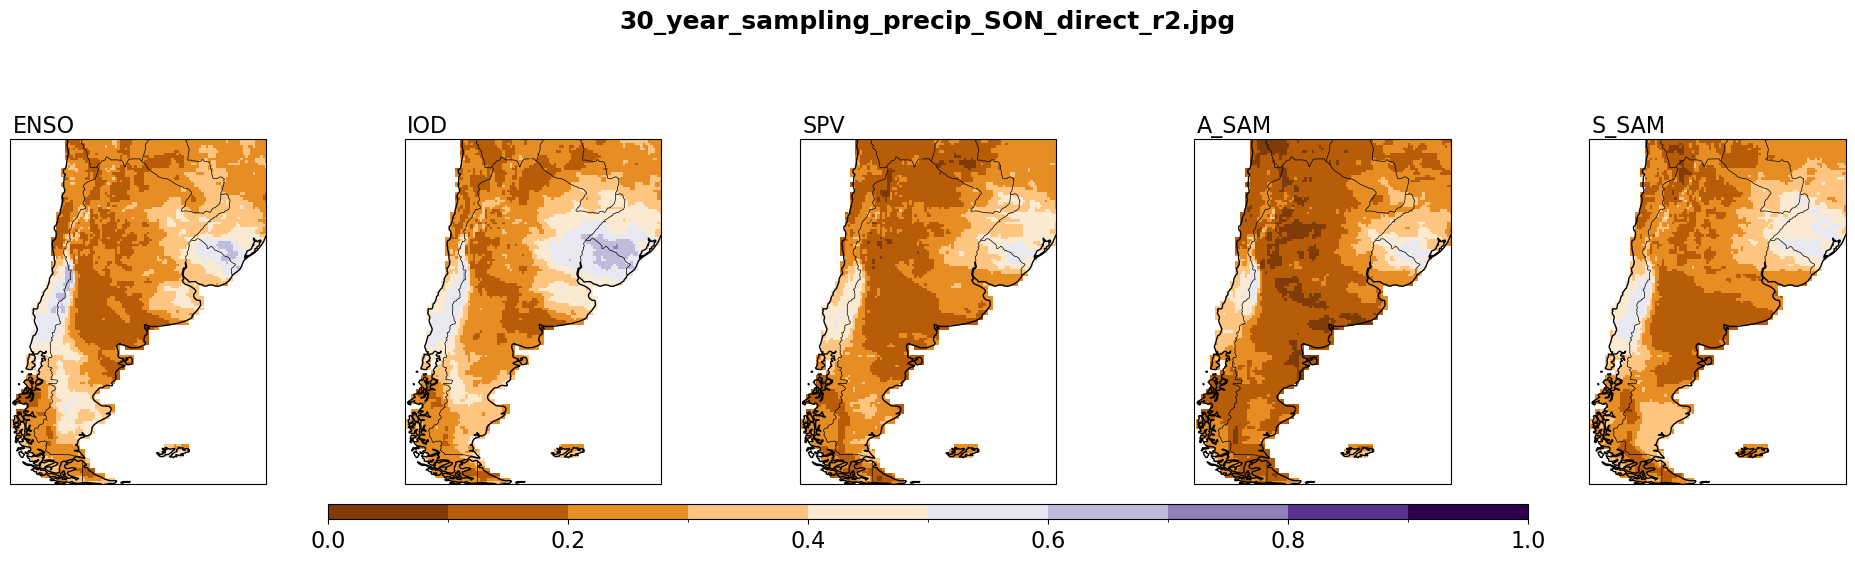

('lat', 'lon')
('lat', 'lon')
('lat', 'lon')


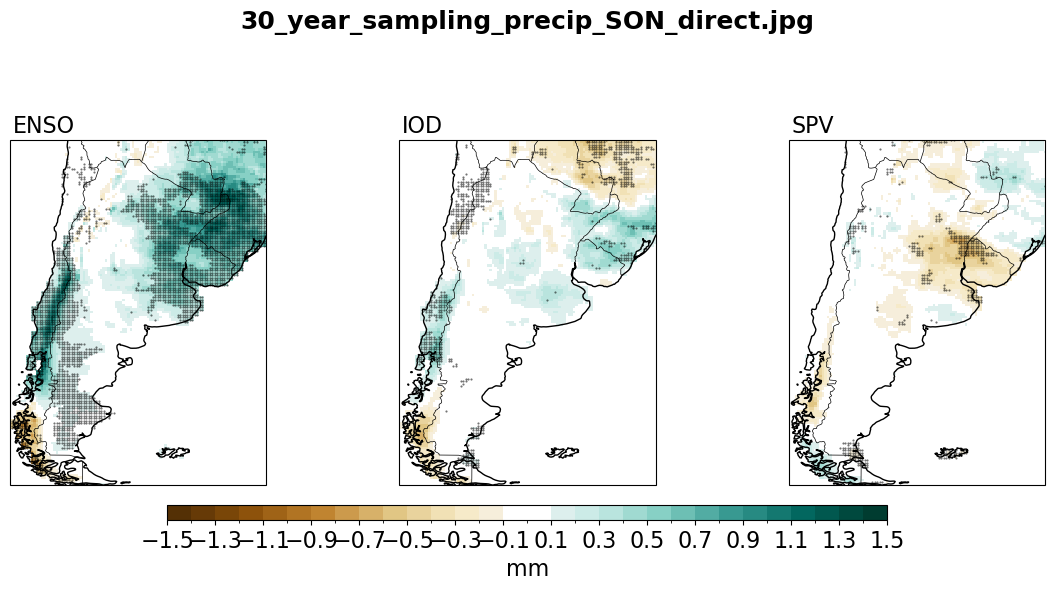

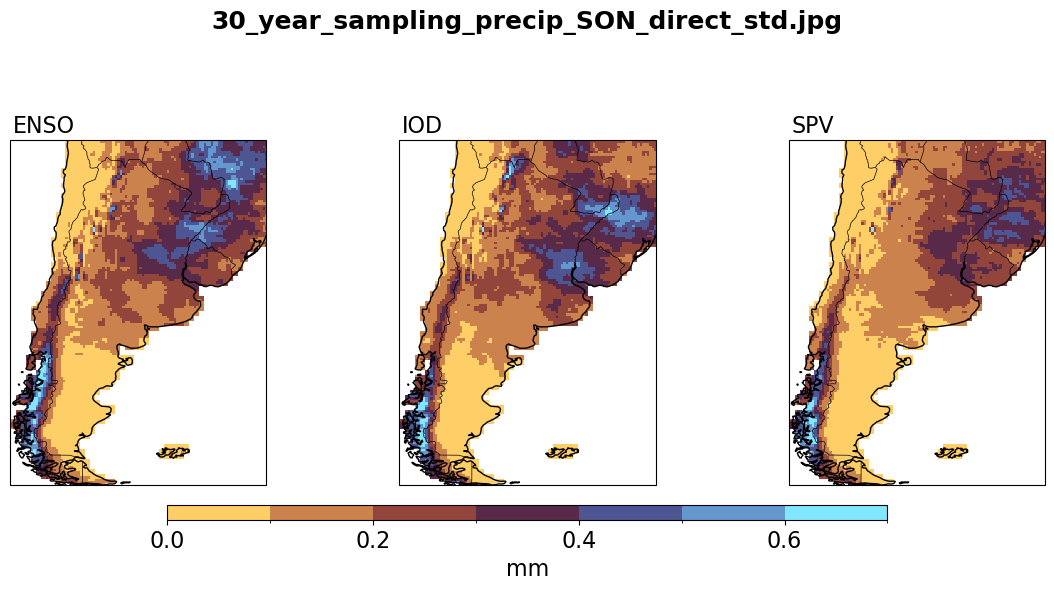

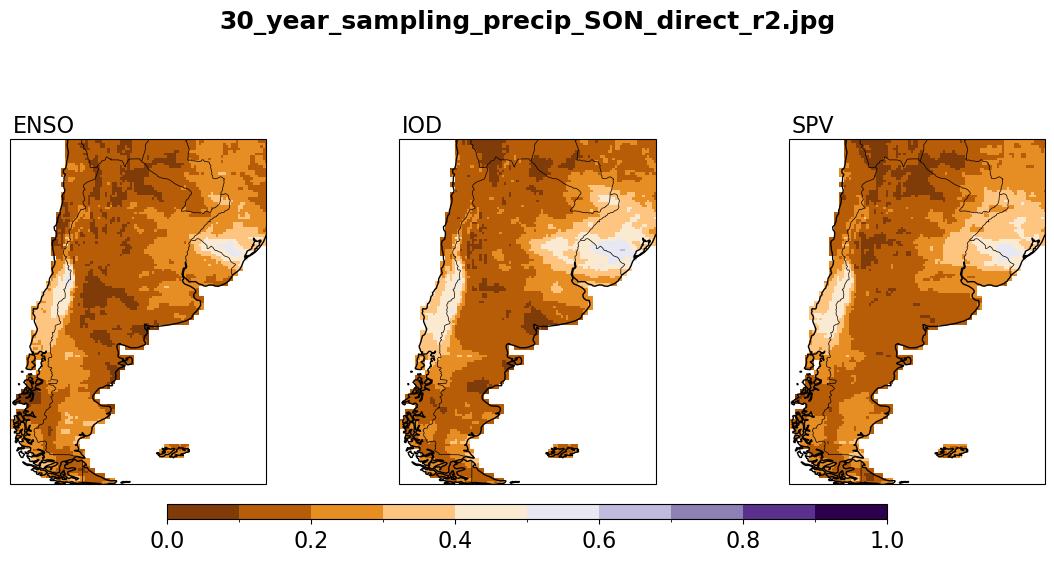

In [16]:
cmap_r2=plt.cm.PuOr
cmap_temp=plt.cm.RdBu_r
cmap_precip=plt.cm.BrBG
cmap_std=plt.cm.managua

subplots_map(coef_precip_SON_direct, drivers_SON, cmap=cmap_precip, unit='mm',
              steps=0.1, heading='30_year_sampling_precip_SON_direct.jpg', BF=significant_precip_SON_direct)
subplots_map(std_precip_SON_direct, drivers_SON, cmap=cmap_std, unit='mm',
              steps=0.1, heading='30_year_sampling_precip_SON_direct_std.jpg', R2_plot=True)

subplots_map(r2_precip_SON_direct, drivers_SON, cmap=cmap_r2, unit='',
              steps=0.1, heading='30_year_sampling_precip_SON_direct_r2.jpg', R2_plot=True)

subplots_map(coef_precip_SON_total, drivers_SON_tot, cmap=cmap_precip, unit='mm',
              steps=0.1, heading='30_year_sampling_precip_SON_direct.jpg', BF=significant_precip_SON_total)
subplots_map(std_precip_SON_total, drivers_SON_tot, cmap=cmap_std, unit='mm',
              steps=0.1, heading='30_year_sampling_precip_SON_direct_std.jpg', R2_plot=True)

subplots_map(r2_precip_SON_total, drivers_SON_tot, cmap=cmap_r2, unit='',
              steps=0.1, heading='30_year_sampling_precip_SON_direct_r2.jpg', R2_plot=True)

Old code

In [ ]:
pr_reg_LP_SON=conditioning_everything_fast(temp_30_years, ['ENSO', 'IOD', 'SPV', 'A_SAM', 'S_SAM'], 'tp')

['IOD', 'SPV', 'A_SAM', 'S_SAM']
ENSO done
['ENSO', 'SPV', 'A_SAM', 'S_SAM']
IOD done
['ENSO', 'IOD', 'S_SAM']
SPV done
['ENSO', 'IOD']
A_SAM done
['ENSO', 'IOD', 'SPV']
S_SAM done


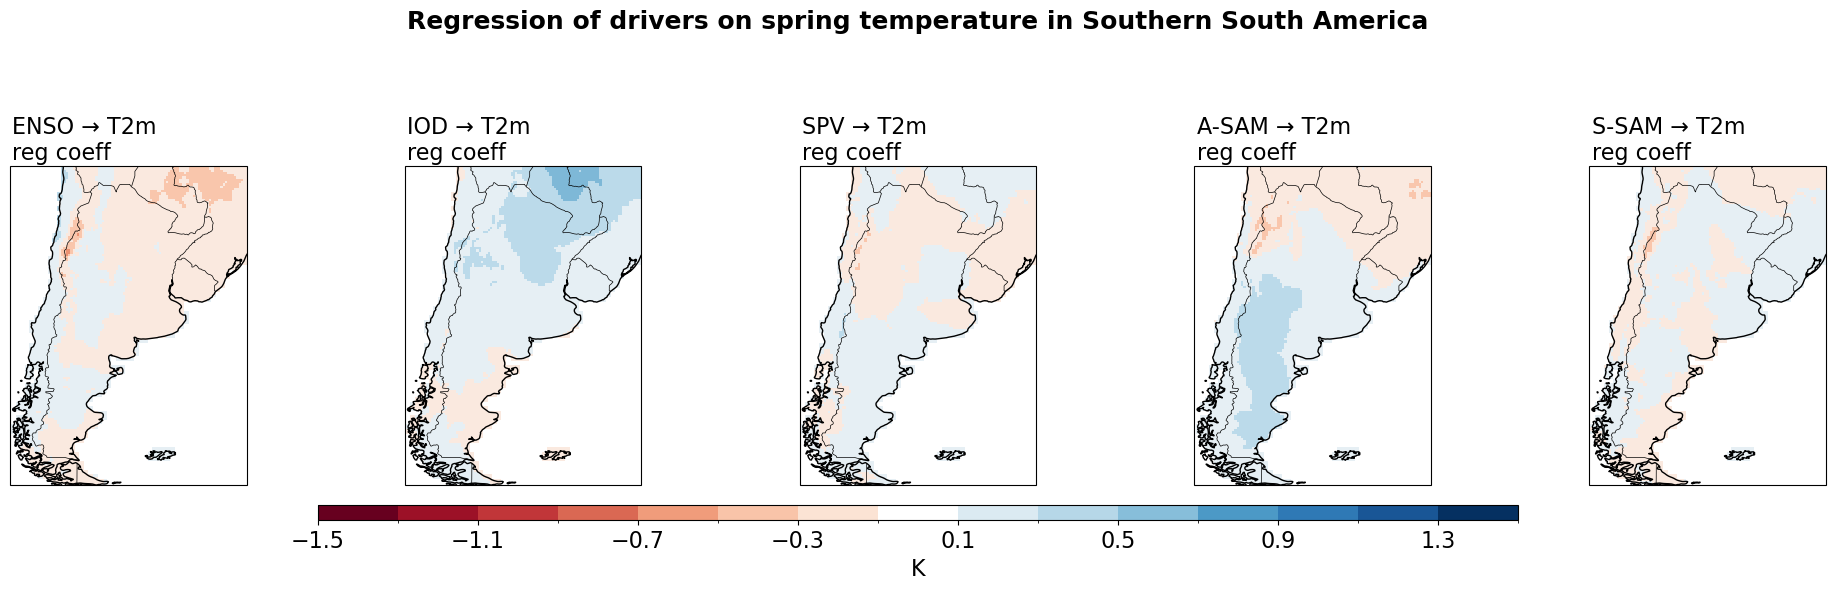

In [ ]:
subplots_map(result, [f"ENSO → T2m \nreg coeff", f"IOD → T2m \nreg coeff", f"SPV → T2m \nreg coeff", \
                      f"A-SAM → T2m \nreg coeff", f"S-SAM → T2m \nreg coeff"],\
                         levels=np.arange(-1.5, 1.51, 0.2), heading='Regression of drivers on spring temperature in Southern South America')

In [ ]:
subplots_map(pr_reg_LP_SON, [f"ENSO → Precip \nreg coeff", f"IOD → Precip \nreg coeff", f"SPV → Precip \nreg coeff", \
                      f"A-SAM → Precip \nreg coeff", f"S-SAM → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG ,heading='Regression of drivers on spring precipitation in Southern South America')

In [ ]:
##total effect of temp and precip in LP
t_reg_LP_SON_tot=conditioning_everything_fast(temp_30_years, ['ENSO', 'IOD', 'SPV'], 't2m',total_eff=True)
pr_reg_LP_SON_tot=conditioning_everything_fast(temp_30_years, ['ENSO', 'IOD', 'SPV'], 'tp',total_eff=True)

None
ENSO done
['ENSO']
IOD done
['ENSO', 'IOD']
SPV done
None
ENSO done
['ENSO']
IOD done
['ENSO', 'IOD']
SPV done


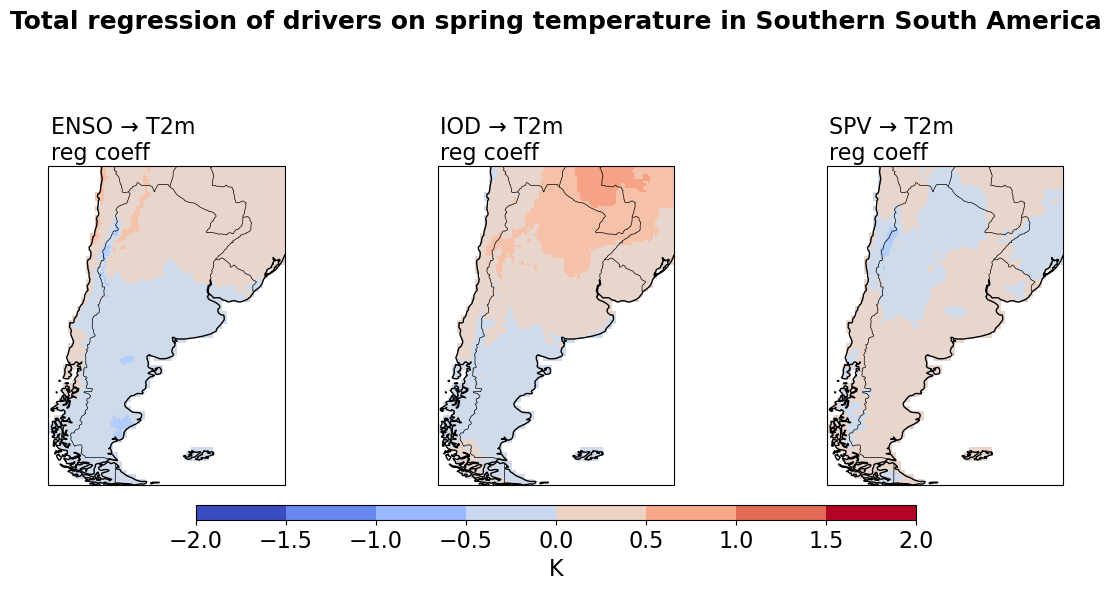

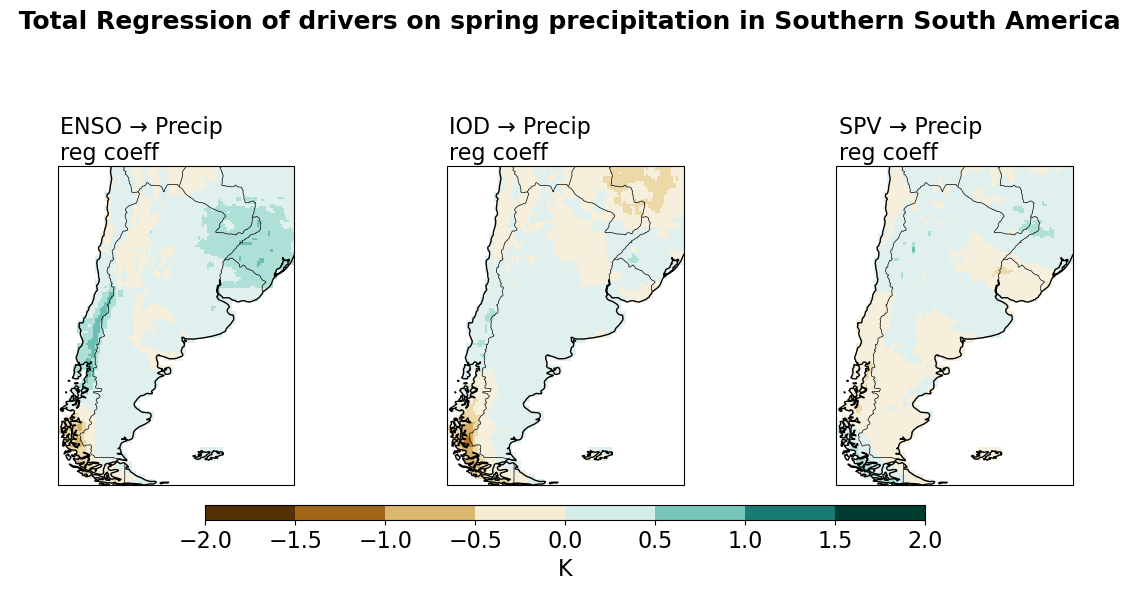

In [ ]:
subplots_map(t_reg_LP_SON_tot, [f"ENSO → T2m \nreg coeff", f"IOD → T2m \nreg coeff", f"SPV → T2m \nreg coeff", \
                      ], levels=np.arange(-1.5, 1.51, 0.2), heading='Total regression of drivers on spring temperature in Southern South America')
subplots_map(pr_reg_LP_SON_tot, [f"ENSO → Precip \nreg coeff", f"IOD → Precip \nreg coeff", f"SPV → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG ,heading=' Total Regression of drivers on spring precipitation in Southern South America')

Whole Area Summer ERA5 data

In [ ]:
temp_30_years_LP_DJF=construct_da_x_year_fix(ds_DJF)
LP_summer_t_reg_old=conditioning_everything_fast(temp_30_years_LP_DJF, ['ENSO', 'IOD', 'SPV', 'A_SAM', 'S_SAM'], 't2m')
LP_summer_pr_reg_old=conditioning_everything_fast(temp_30_years_LP_DJF, ['ENSO', 'IOD', 'SPV', 'A_SAM', 'S_SAM'], 'tp')
LP_summer_t_reg=conditioning_everything_fast(temp_30_years_LP_DJF, ['ENSO', 'IOBW', 'VB', 'A_SAM', 'S_SAM'], 't2m')
LP_summer_pr_reg=conditioning_everything_fast(temp_30_years_LP_DJF, ['ENSO', 'IOBW', 'VB', 'A_SAM', 'S_SAM'], 'tp')

['IOBW', 'VB', 'A_SAM', 'S_SAM']
ENSO done
['ENSO', 'VB', 'A_SAM', 'S_SAM']
IOBW done
['ENSO', 'IOBW', 'S_SAM']
VB done
['ENSO', 'IOBW']
A_SAM done
['ENSO', 'IOBW', 'VB']
S_SAM done
['IOBW', 'VB', 'A_SAM', 'S_SAM']
ENSO done
['ENSO', 'VB', 'A_SAM', 'S_SAM']
IOBW done
['ENSO', 'IOBW', 'S_SAM']
VB done
['ENSO', 'IOBW']
A_SAM done
['ENSO', 'IOBW', 'VB']
S_SAM done


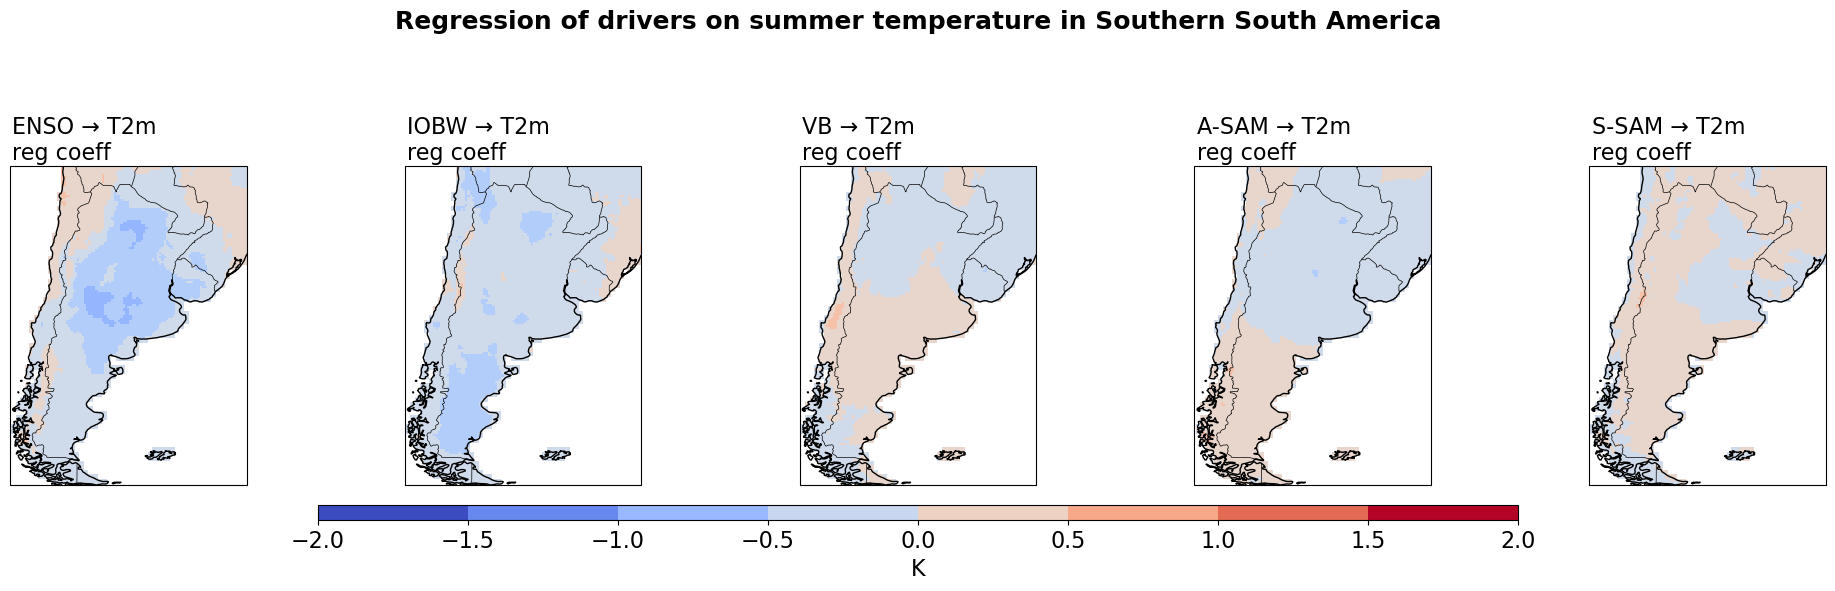

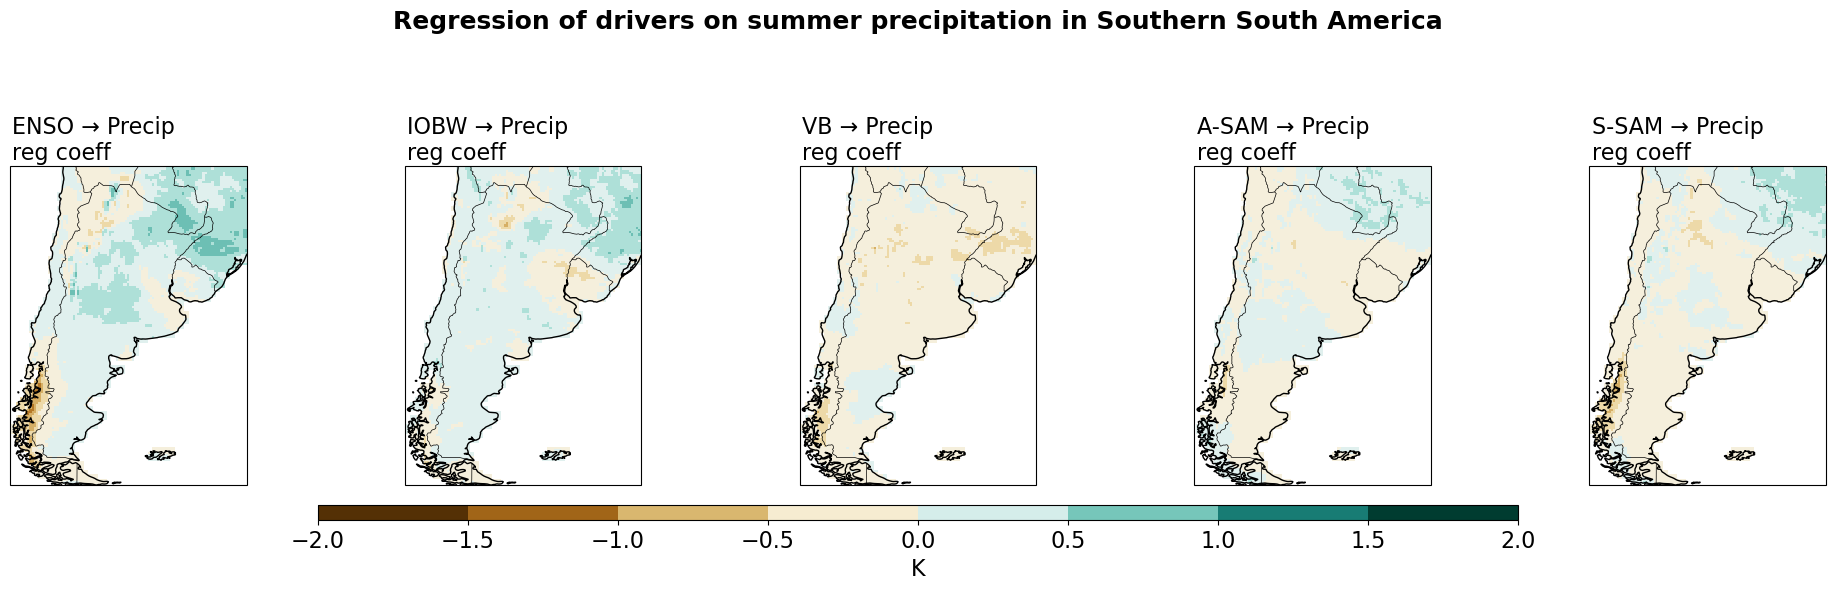

In [ ]:
#print(result)
subplots_map(LP_summer_t_reg_old, [f"ENSO → T2m \nreg coeff", f"IOD → T2m \nreg coeff", f"SPV → T2m \nreg coeff", \
                      f"A-SAM → T2m \nreg coeff", f"S-SAM → T2m \nreg coeff"], \
             heading='Regression of drivers on summer temperature in Southern South America Old')

subplots_map(LP_summer_pr_reg_old, [f"ENSO → Precip \nreg coeff", f"IOD → Precip \nreg coeff", f"SPV → Precip \nreg coeff", \
                      f"A-SAM → Precip \nreg coeff", f"S-SAM → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG ,heading='Regression of drivers on summer precipitation in Southern South America Old')
subplots_map(LP_summer_t_reg, [f"ENSO → T2m \nreg coeff", f"IOBW → T2m \nreg coeff", f"VB → T2m \nreg coeff", \
                      f"A-SAM → T2m \nreg coeff", f"S-SAM → T2m \nreg coeff"], \
             heading='Regression of drivers on summer temperature in Southern South America')

subplots_map(LP_summer_pr_reg, [f"ENSO → Precip \nreg coeff", f"IOBW → Precip \nreg coeff", f"VB → Precip \nreg coeff", \
                      f"A-SAM → Precip \nreg coeff", f"S-SAM → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG ,heading='Regression of drivers on summer precipitation in Southern South America')

In [ ]:
##total effect of temp and precip in LP
t_reg_LP_DJF_tot=conditioning_everything_fast(temp_30_years_LP_DJF, ['ENSO', 'IOBW', 'VB'], 't2m',total_eff=True)
pr_reg_LP_DJF_tot=conditioning_everything_fast(temp_30_years_LP_DJF, ['ENSO', 'IOBW', 'VB'], 'tp',total_eff=True)

None
ENSO done
['ENSO']
IOBW done
['ENSO', 'IOBW']
VB done
None
ENSO done
['ENSO']
IOBW done
['ENSO', 'IOBW']
VB done


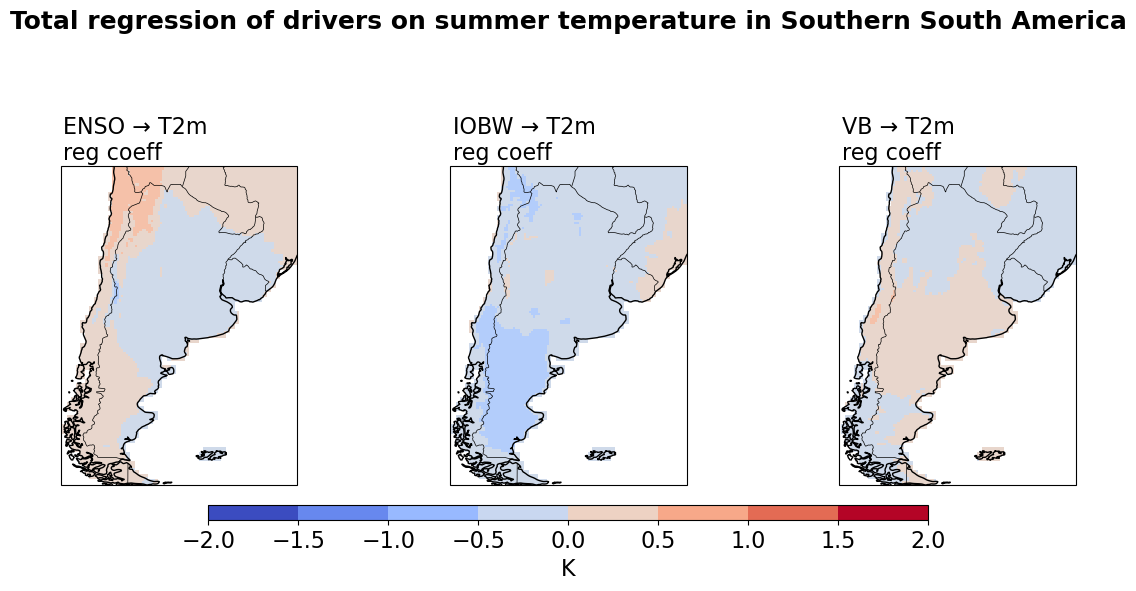

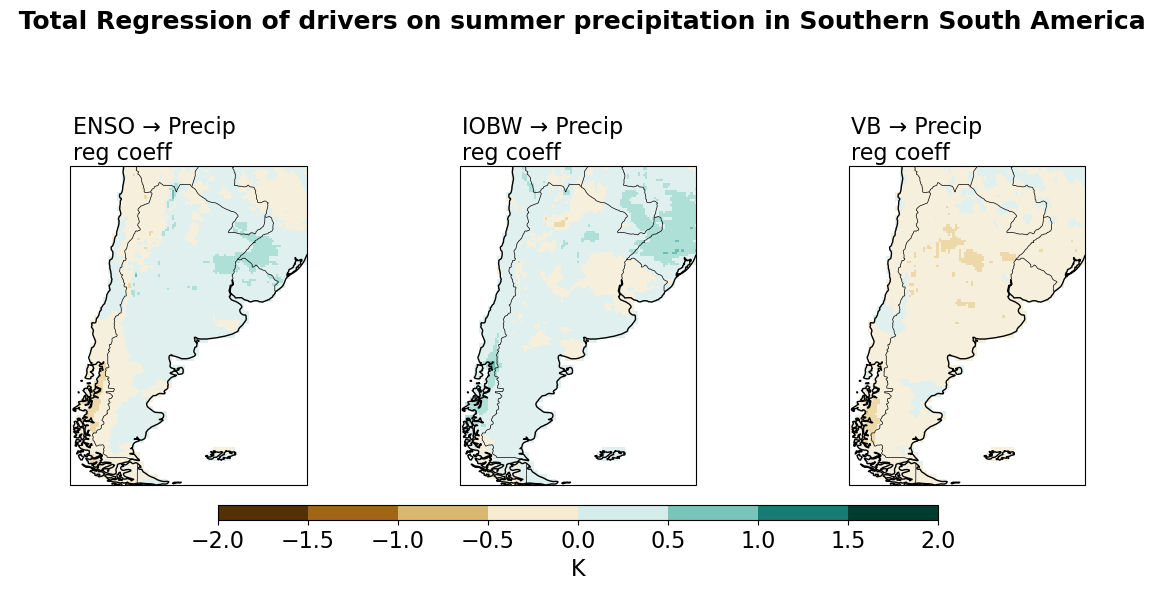

In [ ]:
subplots_map(t_reg_LP_DJF_tot, [f"ENSO → T2m \nreg coeff", f"IOBW → T2m \nreg coeff", f"VB → T2m \nreg coeff", \
                      ], heading='Total regression of drivers on summer temperature in Southern South America')
subplots_map(pr_reg_LP_DJF_tot, [f"ENSO → Precip \nreg coeff", f"IOBW → Precip \nreg coeff", f"VB → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG ,heading=' Total Regression of drivers on summer precipitation in Southern South America')